# Análisis de agrupación por “K vecinos más cercanos”

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [2]:
datos = pd.read_csv('wineclustering.csv')
datos.info()
datos.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


* Determinar el valor promedio de alcohol que tendrían los 5 vinos más parecidos.

In [3]:
datos.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


El valor óptimo de k es: 17


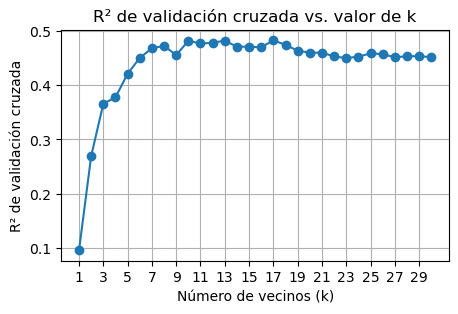

In [4]:
# Separar X e y
X = datos.drop('Alcohol', axis=1)
y = datos['Alcohol']

# Separar bases de training y testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Evaluar KNN con varios k
k_values = list(range(1, 31))
cv_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())

# Mostrar K óptimo
optimal_k = k_values[np.argmax(cv_scores)]
print(f'El valor óptimo de k es: {optimal_k}')

plt.figure(figsize=(5, 3))
plt.plot(k_values, cv_scores, '-o')
plt.title('R² de validación cruzada vs. valor de k')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('R² de validación cruzada')
plt.xticks(k_values[::2])
plt.grid(True)
plt.show()

In [5]:
# Definir el número de vecinos
k = 17
# Definir punto a relacionar
test_data = [17, 0.49]
datos = np.array(datos)

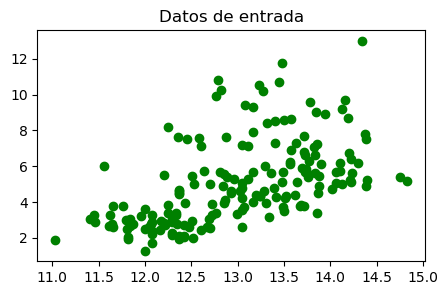

In [6]:
# Visualización de los puntos de la población
plt.figure(figsize=(5,3))
plt.title('Datos de entrada')
plt.scatter(datos[:,0],datos[:,9], marker = 'o', color = 'green')

In [7]:
# Ejecución del algoritmp KNN vecinos
datos = np.random.rand(20, 13) 

# Crear modelo KNN
k = 5
knn_model = NearestNeighbors(n_neighbors=k, algorithm='auto').fit(datos)

# Crear un test_data con 13 características también un solo punto de prueba
test_data = np.random.rand(13) 

# Reshape para que sea un vector de 1 muestra, 13 características
test_data = test_data.reshape(1, -1)

# Calcular vecinos
distances, indices = knn_model.kneighbors(test_data)

# Mostrar vecinos
print('K vecinos más cercanos:')
for rank, index in enumerate(indices[0], start=1):
    print(f"{rank}: {datos[index]}")

K vecinos más cercanos:
1: [0.20660531 0.52921794 0.16670891 0.04930893 0.10214843 0.86080933
 0.28938767 0.60067017 0.32342742 0.30160793 0.97886597 0.63403673
 0.54875589]
2: [0.56338078 0.02261386 0.79190879 0.17598738 0.5791406  0.96732229
 0.31167321 0.81242501 0.33076331 0.77327539 0.74525604 0.89313066
 0.62777111]
3: [0.54919584 0.5126384  0.77544603 0.25457416 0.75919467 0.98760613
 0.40618785 0.09971391 0.66971804 0.78125625 0.18262379 0.60059543
 0.49961978]
4: [0.48412352 0.62295461 0.25803904 0.63255899 0.87425888 0.6861215
 0.0951807  0.23652758 0.58287567 0.13490953 0.90367396 0.26381202
 0.86687256]
5: [0.10011293 0.28416898 0.11341527 0.24860065 0.1929373  0.57894989
 0.77176468 0.16420798 0.27009781 0.73953527 0.42291694 0.86610011
 0.73134008]


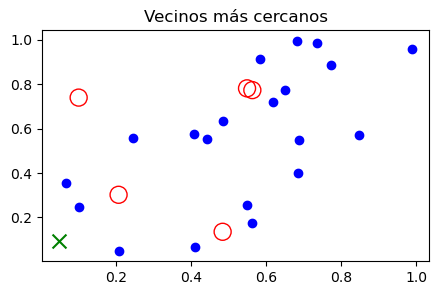

In [8]:
# Visualización de puntos ajustados al punto de interés
plt.figure(figsize=(5,3))
plt.title('Vecinos más cercanos')
plt.scatter(datos[:,0], datos[:,3], marker = 'o', color = 'blue')
plt.scatter(datos[indices][0][:][:,0], datos[indices][0][:][:,9], marker = 'o', s = 150, color = 'red', facecolors = 'none')
plt.scatter(test_data[0][0], test_data[0][1], marker='x', s=100, color='green', label='Punto de prueba')
plt.show()

In [9]:
vecinos_etiquetas = y[indices[0]]
promedio_etiquetas = vecinos_etiquetas.mean()

print(f"Etiquetas de los vecinos: \n {vecinos_etiquetas}")
print(f"Promedio de las etiquetas de los vecinos: \n {promedio_etiquetas}")

Etiquetas de los vecinos: 
 4    13.24
7    14.06
6    14.39
5    14.20
9    13.86
Name: Alcohol, dtype: float64
Promedio de las etiquetas de los vecinos: 
 13.95


# Análisis de patrones de consumo por “Market basket”.

In [10]:
# Definición de puntos de la población
my_basket = [
    ['bread', 'butter', 'wine','bananas', 'coffee', 'carrots'],
    ['tomatoes', 'onions', 'cheese','milk', 'potatoes'],
    ['beer', 'chips', 'asparagus','salsa', 'milk', 'apples'],
    ['olive oil', 'bread', 'butter','tomatoes', 'steak', 'carrots'],
    ['tomatoes', 'onions', 'chips','wine', 'ketchup', 'orange juice'],
    ['bread', 'butter', 'beer','chips', 'milk'],
    ['butter', 'tomatoes', 'carrots','coffee', 'sugar'],
    ['tomatoes', 'onions', 'cheese','milk', 'potatoes'],
    ['bread', 'butter', 'ketchup','coffee', 'chicken wings'],
    ['butter','beer', 'chips','asparagus', 'apples'],
    ['tomatoes', 'onion', 'beer','chips', 'milk', 'coffee']]

my_basket

[['bread', 'butter', 'wine', 'bananas', 'coffee', 'carrots'],
 ['tomatoes', 'onions', 'cheese', 'milk', 'potatoes'],
 ['beer', 'chips', 'asparagus', 'salsa', 'milk', 'apples'],
 ['olive oil', 'bread', 'butter', 'tomatoes', 'steak', 'carrots'],
 ['tomatoes', 'onions', 'chips', 'wine', 'ketchup', 'orange juice'],
 ['bread', 'butter', 'beer', 'chips', 'milk'],
 ['butter', 'tomatoes', 'carrots', 'coffee', 'sugar'],
 ['tomatoes', 'onions', 'cheese', 'milk', 'potatoes'],
 ['bread', 'butter', 'ketchup', 'coffee', 'chicken wings'],
 ['butter', 'beer', 'chips', 'asparagus', 'apples'],
 ['tomatoes', 'onion', 'beer', 'chips', 'milk', 'coffee']]

In [11]:
articulos_unicos = set()
for carrito in my_basket:
    articulos_unicos.update(carrito)
articulos_unicos = sorted(articulos_unicos)
def convertir_a_binario(carrito, lista_articulos):
    return [1 if articulo in carrito else 0 for articulo in lista_articulos]
binario_basket = [convertir_a_binario(carrito, articulos_unicos) for carrito in my_basket]
for i, carrito_binario in enumerate(binario_basket):
    print(f"Carrito {i+1}: {carrito_binario}")

Carrito 1: [0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Carrito 2: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0]
Carrito 3: [1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
Carrito 4: [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0]
Carrito 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1]
Carrito 6: [0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Carrito 7: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0]
Carrito 8: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0]
Carrito 9: [0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Carrito 10: [1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Carrito 11: [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0]


In [12]:
# Aplicación del algoritmo 'a priori' para localizar los artículos frecuentemente comprados
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
# Convertir las transacciones a un array binario
te = TransactionEncoder()
te_ary = te.fit_transform(my_basket)

# Crear DataFrame binario
carrito_binario = pd.DataFrame(te_ary, columns=te.columns_)

# Obtener artículos frecuentes
articulos_frecuentes = apriori(carrito_binario, min_support=0.03, use_colnames = True).sort_values('support', ascending = False).reset_index(drop=True)
articulos_frecuentes['length'] = articulos_frecuentes['itemsets'].apply(lambda x:len(x))
articulos_frecuentes

,support,itemsets,length
0,0.545455,(butter),1
1,0.545455,(tomatoes),1
2,0.454545,(chips),1
3,0.454545,(milk),1
4,0.363636,"(butter, bread)",2
...,...,...,...
391,0.090909,"(milk, coffee, beer)",3
392,0.090909,"(tomatoes, chips, beer)",3
393,0.090909,"(salsa, chips, beer)",3
394,0.090909,"(onion, chips, beer)",3


In [13]:
# Reglas de asociación
from mlxtend.frequent_patterns import association_rules
association_rules(articulos_frecuentes, metric = 'confidence', min_threshold = 0.5).sort_values('confidence', ascending = False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1403,"(butter, wine, bread, coffee)",(carrots),0.090909,0.272727,0.090909,1.0,3.666667,1.0,0.066116,inf,0.800000,0.333333,1.000000,0.666667
2398,"(milk, apples)",(asparagus),0.090909,0.181818,0.090909,1.0,5.500000,1.0,0.074380,inf,0.900000,0.500000,1.000000,0.750000
2410,(steak),(tomatoes),0.090909,0.545455,0.090909,1.0,1.833333,1.0,0.041322,inf,0.500000,0.166667,1.000000,0.583333
1471,"(butter, asparagus)","(apples, chips, beer)",0.090909,0.181818,0.090909,1.0,5.500000,1.0,0.074380,inf,0.900000,0.500000,1.000000,0.750000
2409,(sugar),(tomatoes),0.090909,0.545455,0.090909,1.0,1.833333,1.0,0.041322,inf,0.500000,0.166667,1.000000,0.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1470,"(asparagus, beer)","(butter, apples, chips)",0.181818,0.090909,0.090909,0.5,5.500000,1.0,0.074380,1.818182,1.000000,0.500000,0.450000,0.750000
2411,(wine),(orange juice),0.181818,0.090909,0.090909,0.5,5.500000,1.0,0.074380,1.818182,1.000000,0.500000,0.450000,0.750000
1468,"(apples, chips, beer)","(butter, asparagus)",0.181818,0.090909,0.090909,0.5,5.500000,1.0,0.074380,1.818182,1.000000,0.500000,0.450000,0.750000
1466,"(butter, chips, beer)","(apples, asparagus)",0.181818,0.181818,0.090909,0.5,2.750000,1.0,0.057851,1.636364,0.777778,0.333333,0.388889,0.500000


In [14]:
association_rules(articulos_frecuentes, metric = 'lift', min_threshold = 1.0).sort_values('lift', ascending = False).reset_index(drop=True)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(tomatoes, ketchup, onions)",(orange juice),0.090909,0.090909,0.090909,1.0,11.0,1.0,0.082645,inf,1.000000,1.000000,1.000000,1.00
1,"(tomatoes, beer)","(milk, onion, coffee, chips)",0.090909,0.090909,0.090909,1.0,11.0,1.0,0.082645,inf,1.000000,1.000000,1.000000,1.00
2,"(bread, chicken wings)","(butter, ketchup)",0.090909,0.090909,0.090909,1.0,11.0,1.0,0.082645,inf,1.000000,1.000000,1.000000,1.00
3,"(coffee, chips)","(milk, onion, tomatoes, beer)",0.090909,0.090909,0.090909,1.0,11.0,1.0,0.082645,inf,1.000000,1.000000,1.000000,1.00
4,"(onion, tomatoes)","(milk, coffee, chips, beer)",0.090909,0.090909,0.090909,1.0,11.0,1.0,0.082645,inf,1.000000,1.000000,1.000000,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3633,(milk),"(coffee, tomatoes)",0.454545,0.181818,0.090909,0.2,1.1,1.0,0.008264,1.022727,0.166667,0.166667,0.022222,0.35
3634,(asparagus),(milk),0.181818,0.454545,0.090909,0.5,1.1,1.0,0.008264,1.090909,0.111111,0.166667,0.083333,0.35
3635,(milk),(asparagus),0.454545,0.181818,0.090909,0.2,1.1,1.0,0.008264,1.022727,0.166667,0.166667,0.022222,0.35
3636,(wine),(chips),0.181818,0.454545,0.090909,0.5,1.1,1.0,0.008264,1.090909,0.111111,0.166667,0.083333,0.35
